In [1]:
import pandas as pd, numpy as np

%load_ext autoreload
%autoreload 2

!date

Thu 15 Aug 2024 10:44:13 PM PDT


# HCES Data Extraction
We have HCES data to inform rice consumption (of PSD-distributed and non-PSD rice) by women and birthing people of 
reproductive age (WBPRA) and U5 children in India. We need to do further investigation as to what percentage of PSD-
distributed rice has been fortified with iron and folate.

HCES data and documentation is saved on Sharepoint here: https://uwnetid.sharepoint.com/:f:/r/sites/ihme_simulation_science_team/Shared%20Documents/Research/LSFF/07_Data/HCES_22_data_files?csf=1&web=1&e=wmxQSD

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.
- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

We also will need to approximate DHS wealth quintiles in the HCES data, by using similar variables as is used by the DHS to 
calculate wealth quintiles in India (see DHS wealth quintile documentation here: 
https://dhsprogram.com/programming/wealth%20index/India%20DHS%202015-16/India%202015-16%20sps.txt)

In this notebook, we extract the raw data from the HCES website and do some initial processing in order to create files 
that we can further tabulate based on our project needs in a later step. For now, we process these raw data into dataframes 
that have a row for each household/individual with the following columns:
- Whether or not rice was consumed (binary variable - this will be used to calculate coverage percentages later)
- Amount of PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate fortified rice consumption amount) 
- Amount of non-PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate unfortified rice consumption amount) 
- Wealth composite score/quintile 
- Sex/gender (will be used to calculate WBPRA)
- Age (will be used to tabulate age groups)

## Load data

In [2]:
data_dir = "/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023"

In [3]:
level_1_widths = [4, 4, 5, 1, 2, 3, 2, 2, 2, 2, 1, 4, 2, 1, 1, 2, 1, 2, 1, 1, 15]

level_1 = pd.read_fwf(
    f"{data_dir}/hces22_lvl_01.TXT",
    header=None,
    widths=level_1_widths,
    names=[
        "survey_name",
        "year",
        "fsu_serial_no",
        "sector",
        "state",
        "nss_region",
        "district",
        "stratum",
        "sub_stratum",
        "panel",
        "sub_sample",
        "fod_sub_region",
        "sample_su_no",
        "sample_sub_division_no",
        "second_stage_stratum_no",
        "sample_household_no",
        "questionnaire_no",
        "level",
        "survey_code",
        "reason_for_substitution_code",
        "multiplier",
    ],
)
level_1

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,fod_sub_region,sample_su_no,sample_sub_division_no,second_stage_stratum_no,sample_household_no,questionnaire_no,level,survey_code,reason_for_substitution_code,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,2,1,H,1,1,NaN,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,1,H,1,1,NaN,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,2,H,1,1,NaN,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,3,H,1,1,NaN,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,4,H,1,1,NaN,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,14,H,1,1,NaN,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,15,H,1,1,NaN,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,16,H,1,1,NaN,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,17,H,1,1,NaN,73515.0


In [4]:
common_id_columns = level_1.columns[:16]
common_id_column_widths = level_1_widths[:16]

level_1["common_id"] = ""

for col, width in zip(common_id_columns, common_id_column_widths):
    fill_val = "0"
    side = "left"
    if col in ("sample_su_no", "sample_sub_division_no", "panel"):
        # No clue.
        fill_val = " "
        side = "right"

    values = (
        level_1[col]
        .fillna(fill_val)
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.pad(width, fillchar=fill_val, side=side)
    )
    assert (values.str.len() == width).all()
    level_1["common_id"] += values

level_1["common_id"]

0         HCES2022655561010131113011 101202  201
1         HCES2022655561010131113011 101202  301
2         HCES2022655561010131113011 101202  302
3         HCES2022655561010131113011 101202  303
4         HCES2022655561010131113011 101202  304
                           ...                  
261741    HCES20223951022828313220210228101  314
261742    HCES20223951022828313220210228101  315
261743    HCES20223951022828313220210228101  316
261744    HCES20223951022828313220210228101  317
261745    HCES20223951022828313220210228101  318
Name: common_id, Length: 261746, dtype: object

In [5]:
level_3 = pd.read_fwf(
    "/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_03.TXT",
    header=None,
    widths=[
        38,
        1,
        2,
        2,
        1,
        3,
        5,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        9,
        1,
        1,
        1,
        1,
        1,
        2,
        1,
        2,
        3,
        1,
        2,
        1,
        1,
        1,
        1,
        2,
        15,
    ],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "hh_size",
        "household_member_economic_activity_last_365_days",
        "nco_2015_code",
        "nic_2008_code",
        "max_income_source_last_365_days",
        "major_income_source_self_employment_sector",
        "major_income_regular_wage_sector",
        "major_income_casual_labour_sector",
        "household_type",
        "head_religion",
        "head_social_group",
        "land_ownership",
        "land_type_owned",
        "total_owned_land_area",
        "has_dwelling",
        "dwelling_unit_type",
        "building_material_wall",
        "building_material_roof",
        "building_material_floor",
        "cooking_energy_source",
        "lighting_energy_source",
        "drinking_water_source",
        "water_fetching_time_minutes",
        "latrine_access_type",
        "latrine_type",
        "ration_card_type",
        "rural_rent_rate_availability",
        "pmgky_benefit_status",
        "household_child_mortality_last_5_years",
        "child_mortality_count_last_5_years",
        "multiplier",
    ],
)
level_3

,common_id,questionnaire_no,level,hh_size,household_member_economic_activity_last_365_days,nco_2015_code,nic_2008_code,max_income_source_last_365_days,major_income_source_self_employment_sector,major_income_regular_wage_sector,...,drinking_water_source,water_fetching_time_minutes,latrine_access_type,latrine_type,ration_card_type,rural_rent_rate_availability,pmgky_benefit_status,household_child_mortality_last_5_years,child_mortality_count_last_5_years,multiplier
0,HCES2022655561010131113011 101202 201,H,3,5,1,332.0,68200.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,35560.0
1,HCES2022655561010131113011 101202 301,H,3,6,1,931.0,42909.0,3.0,NaN,NaN,...,2,0.0,1,2.0,2,2.0,2,2,0,30331.0
2,HCES2022655561010131113011 101202 302,H,3,8,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
3,HCES2022655561010131113011 101202 303,H,3,4,1,142.0,47713.0,1.0,2.0,NaN,...,2,0.0,1,2.0,0,2.0,2,2,0,30331.0
4,HCES2022655561010131113011 101202 304,H,3,4,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,H,3,2,1,832.0,49219.0,1.0,NaN,NaN,...,11,10.0,1,1.0,4,NaN,1,2,0,73515.0
261742,HCES20223951022828313220210228101 315,H,3,4,1,216.0,85500.0,2.0,NaN,NaN,...,2,0.0,1,1.0,0,NaN,1,2,0,73515.0
261743,HCES20223951022828313220210228101 316,H,3,3,1,411.0,84119.0,2.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0
261744,HCES20223951022828313220210228101 317,H,3,5,1,112.0,47711.0,1.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0


In [6]:
assert level_3.common_id.is_unique

In [7]:
level_3.cooking_energy_source

0         2
1         2
2         2
3         2
4         2
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: cooking_energy_source, Length: 261746, dtype: int64

In [8]:
binary_columns = ["land_ownership", "has_dwelling"]

for col in binary_columns:
    level_3[col] = (
        level_3[col]
        .map(
            {
                1: 1.0,
                2: 0.0,
            }
        )
        .astype(float)
    )

In [9]:
level_3.loc[level_3.land_ownership == 0, "total_owned_land_area"] = 0

In [10]:
level_3["dwelling_unit_type"] = level_3.dwelling_unit_type.map(
    {
        1: "owned",
        2: "hired",
        3: "others",
    }
)
level_3["house_ownership"] = (level_3.has_dwelling == 1) & (
    level_3.dwelling_unit_type == "owned"
)

In [11]:
materials = {
    1: "grass",
    2: "mud",
    3: "canvas",
    4: "katcha",
    5: "tiles",
    6: "brick",
    7: "metal",
    8: "cement",
    9: "pucca",
}

for col in [
    "building_material_wall",
    "building_material_roof",
    "building_material_floor",
]:
    level_3[col] = level_3[col].map(materials)
    level_3.loc[level_3.has_dwelling == 0, col] = "none"

In [12]:
level_3["cooking_energy_source"] = level_3.cooking_energy_source.map(
    {
        1: "firewood",
        2: "liquid petroleum gas",
        3: "other natural gas",
        4: "dung",
        5: "kerosene",
        6: "coal",
        7: "gobar",
        8: "other biogas",
        10: "charcoal",
        11: "electricity",
        12: "no cooking",
        9: "other",
    }
)

In [13]:
level_3["lighting_energy_source"] = level_3.lighting_energy_source.map(
    {
        1: "electricity",
        2: "kerosene",
        3: "other oil",
        4: "gas",
        5: "candle",
        6: "no lighting",
        9: "other",
    }
)

In [14]:
level_3["drinking_water_source"] = level_3.drinking_water_source.map(
    {
        1: "bottled",
        2: "piped into dwelling",
        3: "piped to yard",
        4: "piped from neighbor",
        5: "public tap",
        6: "tube well",
        7: "hand pump",
        8: "well: protected",
        9: "well: unprotected",
        10: "tanker-truck: public",
        11: "tanker-truck: private",
        12: "spring: protected",
        13: "spring: unprotected",
        14: "rainwater collection",
        15: "tank or pond",
        16: "other surface water",
        19: "other",
    }
)

In [15]:
level_3["latrine_access_type"] = level_3.latrine_access_type.map(
    {
        1: "exclusive",
        2: "common",
        3: "public, free",
        4: "public, paid",
        5: "no latrine",
        9: "other",
    }
)

In [16]:
level_3["latrine_type"] = level_3.latrine_type.map(
    {
        1: "flush to piped",
        2: "flush to septic",
        3: "flush to twin leach pit",
        4: "flush to single leach pit",
        5: "other flush",
        6: "improved pit",
        7: "pit with slab",
        8: "pit without slab",
        10: "composting",
        11: "open",
        19: "other",
    }
)

In [17]:
level_3["latrine_access_and_type"] = np.where(
    level_3.latrine_access_type == "no latrine",
    "no latrine",
    np.where(
        level_3.latrine_access_type.notnull() & level_3.latrine_type.notnull(),
        (level_3["latrine_access_type"] == "exclusive").map(
            {True: "", False: "shared "}
        )
        + level_3.latrine_type,
        np.nan,
    ),
)

<Axes: >

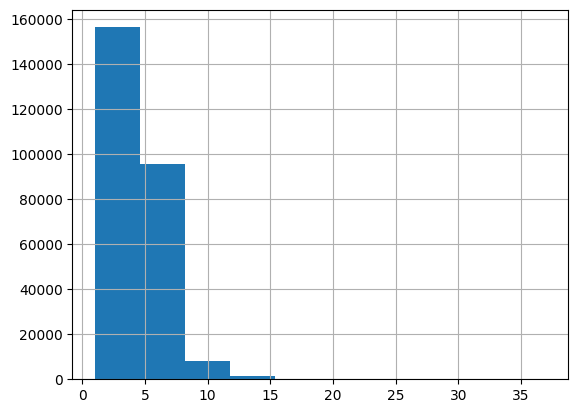

In [18]:
# The fact that there are a couple very large households (e.g. 20+ members) is a little
# surprising - maybe we can investigate to confirm these are some kind of GQ.
level_3.hh_size.hist()

In [19]:
level_7 = pd.read_fwf(
    f"{data_dir}/hces22_lvl_07.TXT",
    header=None,
    widths=[
        38,
        1,
        2,
        1,
        1,
        2,
        1,
        1,
        3,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        2,
        1,
        2,
        1,
        1,
        2,
        8,
        1,
        1,
        1,
        1,
        1,
        1,
        15,
    ],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "kerosene",
        "lpg_subsidy",
        "num_lpg_subsidy",
        "days",
        "attend_education",
        "unk",
        "num_attend_priv_ed",
        "free_items",
        "free_textbooks",
        "free_stationary",
        "num_free_stationary",
        "free_school_bag",
        "num_free_school_bag",
        "other_free_items",
        "num_other_free_items",
        "fee_waiver",
        "num_free_waiver",
        "benefit_pmjay",
        "num_benefit_pmjay",
        "hospitalization",
        "pmjay_hosp_benefit",
        "pmjay_hosp_benefit_num",
        "pmjay_hosp_benefit_amt",
        "fuel_light",
        "toilet",
        "education",
        "medicine",
        "services",
        "internet",
        "multiplier",
    ],
)
level_7

,common_id,questionnaire_no,level,kerosene,lpg_subsidy,num_lpg_subsidy,days,attend_education,unk,num_attend_priv_ed,...,pmjay_hosp_benefit,pmjay_hosp_benefit_num,pmjay_hosp_benefit_amt,fuel_light,toilet,education,medicine,services,internet,multiplier
0,HCES2022655561010131113011 101202 201,C,7,2,1,1.0,2,1,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,35560.0
1,HCES2022655561010131113011 101202 301,C,7,2,1,1.0,2,1,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
2,HCES2022655561010131113011 101202 302,C,7,2,1,2.0,2,1,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
3,HCES2022655561010131113011 101202 303,C,7,2,2,NaN,2,1,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
4,HCES2022655561010131113011 101202 304,C,7,2,1,1.0,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261742,HCES20223951022828313220210228101 315,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261743,HCES20223951022828313220210228101 316,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,73515.0
261744,HCES20223951022828313220210228101 317,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0


In [20]:
assert level_7.common_id.is_unique

In [21]:
binary_columns = ["internet"]

for col in binary_columns:
    level_7[col] = (
        level_7[col]
        .map(
            {
                1: 1.0,
                2: 0.0,
            }
        )
        .astype(float)
    )

In [22]:
level_11 = pd.read_fwf(
    "/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_11.TXT",
    header=None,
    widths=[
        38,
        1,
        2,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        3,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        15,
    ],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "clothing",
        "footwear",
        "furniture",
        "recently_bought_mobile_handset",
        "personal_goods",
        "recreation_goods",
        "cooking",
        "crockery",
        "sports_goods",
        "med_equip",
        "bedding",
        "free_laptop",
        "num_free_laptop",
        "free_tablet",
        "num_free_tablet",
        "free_mobile",
        "num_free_mobile",
        "free_bicycle",
        "num_free_bicycle",
        "free_motorcycle",
        "num_free_motorcycle",
        "free_clothing",
        "num_free_clothing",
        "free_footwear",
        "num_free_footwear",
        "other_free",
        "num_other_free",
        "tv",
        "radio",
        "laptop",
        "mobile_handset",
        "bicycle",
        "motorcycle",
        "motor_car",
        "trucks",
        "animal_cart",
        "refrigerator",
        "washing_machine",
        "air_conditioner",
        "multichannel_tv_type",
        "multiplier",
    ],
)
level_11

,common_id,questionnaire_no,level,clothing,footwear,furniture,recently_bought_mobile_handset,personal_goods,recreation_goods,cooking,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2022655561010131113011 101202 201,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,NaN,NaN,1.0,1.0,NaN,3.0,35560.0
1,HCES2022655561010131113011 101202 301,D,11,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
2,HCES2022655561010131113011 101202 302,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,3.0,30331.0
3,HCES2022655561010131113011 101202 303,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
4,HCES2022655561010131113011 101202 304,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,2.0,73515.0
261742,HCES20223951022828313220210228101 315,D,11,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,73515.0
261743,HCES20223951022828313220210228101 316,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,73515.0
261744,HCES20223951022828313220210228101 317,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,2.0,73515.0


In [23]:
assert level_11.common_id.is_unique

In [24]:
level_11.tv.value_counts(dropna=False)

1.0    180715
NaN     81031
Name: tv, dtype: int64

In [25]:
possession_columns = [
    "tv",
    "radio",
    "laptop",
    "mobile_handset",
    "bicycle",
    "motorcycle",
    "motor_car",
    "trucks",
    "animal_cart",
    "refrigerator",
    "washing_machine",
    "air_conditioner",
]

In [26]:
level_11[possession_columns].isnull().mean()

tv                 0.309579
radio              0.968076
laptop             0.918024
mobile_handset     0.032975
bicycle            0.594745
motorcycle         0.454517
motor_car          0.916770
trucks             0.998418
animal_cart        0.992428
refrigerator       0.565185
washing_machine    0.779699
air_conditioner    0.753521
dtype: float64

In [27]:
(level_11[possession_columns] == 0).mean()

tv                 0.0
radio              0.0
laptop             0.0
mobile_handset     0.0
bicycle            0.0
motorcycle         0.0
motor_car          0.0
trucks             0.0
animal_cart        0.0
refrigerator       0.0
washing_machine    0.0
air_conditioner    0.0
dtype: float64

In [28]:
for col in possession_columns:
    level_11[col] = level_11[col].fillna(0.0)

In [29]:
household_levels = [level_1, level_3, level_7, level_11]

In [30]:
level_specific_columns = ["level", "questionnaire_no"]


def drop_level_specific(df):
    return df[[c for c in df.columns if c not in level_specific_columns]]


households = drop_level_specific(household_levels[0])

for additional_level in household_levels[1:]:
    common_columns = (set(households.columns) & set(additional_level.columns)) - {
        "common_id"
    }
    households = households.merge(
        drop_level_specific(additional_level),
        on="common_id",
        validate="1:1",
        how="outer",
    )
    for column in common_columns:
        assert (households[f"{column}_x"] == households[f"{column}_y"]).all()
        households[column] = households[f"{column}_x"]
        households = households.drop(columns=[f"{column}_x", f"{column}_y"])

households

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,73515.0


In [31]:
# Bizarrely, I can't find documentation of these codes -- but we know the rent rate is only asked for rural
households.assign(rent_rate=households.rural_rent_rate_availability.notnull()).groupby(
    "sector"
).rent_rate.mean()

sector
1    1.0
2    0.0
Name: rent_rate, dtype: float64

In [32]:
households["sector"] = households.sector.map({1: "rural", 2: "urban"})
households.sector.value_counts(dropna=False)

rural    155014
urban    106732
Name: sector, dtype: int64

In [33]:
households.isnull().mean().sort_values()

survey_name                0.000000
building_material_floor    0.000000
cooking_energy_source      0.000000
lighting_energy_source     0.000000
drinking_water_source      0.000000
                             ...   
free_laptop                0.999282
num_free_mobile            0.999366
free_mobile                0.999366
num_free_motorcycle        0.999893
free_motorcycle            0.999893
Length: 121, dtype: float64

## Calculate wealth quintiles

In order to add wealth stratifications into our HCES data, we will emulate DHS methods for calculating wealth quintiles.
They don't ask something like "how wealthy are you?"
Instead, they ask "do you have a refrigerator?" and then a bunch of other questions like that,
and analyze them into a composite wealth index.
The way they do so is actually pretty weird and interesting, but I won't get into that here.
It is described at https://dhsprogram.com/topics/wealth-index/Wealth-Index-Construction.cfm.

In a first pass, we attempted to use the DHS weights directly.
See [this past version of the notebook](https://github.com/ihmeuw/vivarium_gates_lsff_2026_maternal/blob/12d63b4c5a3b7cb204c4f6eb3de7d6ffe87ce9c3/0100_data_prep/01_extract_hces.ipynb)
for how we started to do this.

However, this was tricky,
because none of the questions asked in HCES are exactly the same, with the same answer options,
as in DHS.
We could sort of use proxies and fudge things, but it was pretty rough.
Here, I have instead used the same *methods* used in the DHS to make an entirely new
model of the latent wealth variable.
I followed the steps described here: https://dhsprogram.com/programming/wealth%20index/Steps_to_constructing_the_new_DHS_Wealth_Index.pdf

However, even this is pretty underwhelming. Probably a better strategy to try in the future would be to make a more complex and
precise crosswalk between DHS and HCES questions/responses, then train a model in DHS to predict the DHS wealth quintile based
only on information available in HCES, and finally predict HCES.

DHS wealth index variables include: 
- Source of drinking water
- Type of toilet facility
- Electricity
- Mattress
- Pressure cooker
- Chair
- Cot or bed
- Table
- Electric fan
- Radio or transistor
- Black and white television
- Colour television
- Sewing machine
- Mobile telephone
- Telephone (non-mobile)
- Internet
- Computer
- Refrigerator
- Air conditioner/cooler
- Washing machine
- Watch or clock
- Bicycle
- Motorcycle or Scooter
- Animal-drawn cart
- Car
- Water pump
- Thresher
- Tractor
- Type of cooking fuel
- Main material of floor
- Main roof material
- Main wall material
- Hectares for agricultural land
- Out of this land, how much is irrigated?
- Cows / bulls / buffaloes
- Camels
- Horses / donkeys / mules
- Goats
- Sheep
- Chickens / ducks
- Bank account
- Members per sleeping room
- Compute urban and rural variables coded (1/0) for filters later
- Toilet facility by shared/not shared
- Land area by units - if there are separate units - need to convert them to one unit

HCES variables:
- Type of land owned
- What is the total area of all owned (owned and possessed or leased out) land (within the country) by the household as on the date of survey (area in acre)?(upto two places of decimal) 
- Basic building Material used for major portion of the wall of the dwelling Unit
- Basic building Material used for construction of the major portion of the outer exposed part of the roof of the dwelling unit
- Basic Building Material used for construction of the major portion of the floor of the dwelling Unit
- Source of Drinking Water (Last 365 days)
- Type of latrine in which the household has access
- Primary source of energy of the household for cooking
- Household has internet facility as on the date of the survey
- Whether household possessed one or more item as on the date of the survey- Television 
- Whether household possessed one or more item as on the date of the survey- Radio
- Whether household possessed one or more item as on the date of the survey - Laptop/PC
- Whether household possessed one or more item as on the date of the survey- Mobile handset
- Whether household possessed one or more item as on the date of the survey- Bicycle
- Whether household possessed one or more item as on the date of the survey- Motorcycle, scooter 
- Whether household possessed one or more item as on the date of the survey- Motor car/jeep/van
- Whether household possessed one or more item as on the date of the survey- Trucks
- Whether household possessed one or more item as on the date of the survey - Animal cart
- Whether household possessed one or more item as on the date of the survey- Refrigerator
- Whether household possessed one or more item as on the date of the survey- Washing machine
- Whether household possessed one or more item as on the date of the survey- Air conditioner/air cooler 
- Type of multichannel television facility is used by the household as on the date of the survey

Crosswalk spreadsheet saved here: https://uwnetid.sharepoint.com/sites/ihme_simulation_science_team/_layouts/15/doc.aspx?sourcedoc={eddcbf51-3462-47d7-b847-79edea5046c6}&action=edit

In [34]:
wealth_relevant_info = households[
    [
        "sector",
        "hh_size",
        "multiplier",
        # Section/level 4
        "land_ownership",
        # 'total_owned_land_area',
        "has_dwelling",
        "house_ownership",
        "building_material_wall",
        "building_material_roof",
        "building_material_floor",
        "cooking_energy_source",
        "lighting_energy_source",
        "drinking_water_source",
        # Cross-tab latrine type with whether shared
        "latrine_access_and_type",
        # Section 4.2
        "internet",
        # Section 4.3
        *possession_columns,
    ]
].copy()
wealth_relevant_info

,sector,hh_size,multiplier,land_ownership,has_dwelling,house_ownership,building_material_wall,building_material_roof,building_material_floor,cooking_energy_source,...,laptop,mobile_handset,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner
0,rural,5,35560.0,1.0,1.0,True,brick,cement,cement,liquid petroleum gas,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,rural,6,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,rural,8,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,rural,4,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,rural,4,30331.0,1.0,1.0,True,brick,metal,cement,liquid petroleum gas,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,urban,2,73515.0,0.0,1.0,False,brick,cement,tiles,liquid petroleum gas,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
261742,urban,4,73515.0,1.0,1.0,True,brick,tiles,cement,liquid petroleum gas,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
261743,urban,3,73515.0,0.0,1.0,False,brick,tiles,cement,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
261744,urban,5,73515.0,0.0,1.0,False,brick,cement,tiles,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


In [35]:
wealth_relevant_info.isnull().mean()

sector                     0.0
hh_size                    0.0
multiplier                 0.0
land_ownership             0.0
has_dwelling               0.0
house_ownership            0.0
building_material_wall     0.0
building_material_roof     0.0
building_material_floor    0.0
cooking_energy_source      0.0
lighting_energy_source     0.0
drinking_water_source      0.0
latrine_access_and_type    0.0
internet                   0.0
tv                         0.0
radio                      0.0
laptop                     0.0
mobile_handset             0.0
bicycle                    0.0
motorcycle                 0.0
motor_car                  0.0
trucks                     0.0
animal_cart                0.0
refrigerator               0.0
washing_machine            0.0
air_conditioner            0.0
dtype: float64

In [36]:
wealth_relevant_info.nunique()

sector                         2
hh_size                       31
multiplier                 23607
land_ownership                 2
has_dwelling                   2
house_ownership                2
building_material_wall        10
building_material_roof        10
building_material_floor       10
cooking_energy_source         12
lighting_energy_source         7
drinking_water_source         17
latrine_access_and_type       22
internet                       2
tv                             2
radio                          2
laptop                         2
mobile_handset                 2
bicycle                        2
motorcycle                     2
motor_car                      2
trucks                         2
animal_cart                    2
refrigerator                   2
washing_machine                2
air_conditioner                2
dtype: int64

In [37]:
columns_to_convert = [
    "building_material_wall",
    "building_material_roof",
    "building_material_floor",
    "cooking_energy_source",
    "lighting_energy_source",
    "drinking_water_source",
    "latrine_access_and_type",
]

for column in columns_to_convert:
    # Get dummy variables for the current column
    dummies = pd.get_dummies(wealth_relevant_info[column], prefix=column)

    # Drop the original column from hces_df
    wealth_relevant_info = wealth_relevant_info.drop(column, axis=1)

    # Join the dummy variables to the original DataFrame
    wealth_relevant_info = pd.concat([wealth_relevant_info, dummies], axis=1)

In [38]:
wealth_predictors = [
    c
    for c in wealth_relevant_info.columns
    if c not in ("sector", "hh_size", "multiplier")
]

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(
    wealth_relevant_info.drop(columns=["sector", "multiplier", "hh_size"]).dropna(
        how="any"
    )
)

PCA(n_components=1)

In [40]:
pd.DataFrame(
    {
        "column": wealth_relevant_info.drop(
            columns=["sector", "multiplier", "hh_size"]
        ).columns,
        "scores": pd.Series(pca.components_[0]).astype(float),
    }
).sort_values("scores")

,column,scores
50,cooking_energy_source_firewood,-0.332121
42,building_material_floor_mud,-0.211374
66,drinking_water_source_hand pump,-0.201371
31,building_material_roof_metal,-0.157884
8,bicycle,-0.135724
...,...,...
9,motorcycle,0.246566
4,tv,0.264903
28,building_material_roof_cement,0.269550
53,cooking_energy_source_liquid petroleum gas,0.341292


In [41]:
wealth_relevant_info["common_score"] = pca.transform(
    wealth_relevant_info.drop(columns=["sector", "multiplier", "hh_size"])
)

In [42]:
wealth_relevant_info.sector.value_counts()

rural    155014
urban    106732
Name: sector, dtype: int64

In [43]:
scores = {}

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    pca = PCA(n_components=1)
    pca.fit(wealth_relevant_info[sector_rows][wealth_predictors].dropna(how="any"))

    display(
        pd.DataFrame(
            {
                "column": wealth_predictors,
                "scores": pd.Series(pca.components_[0]).astype(float),
            }
        ).sort_values("scores")
    )

    wealth_relevant_info.loc[sector_rows, f"{sector}_score"] = pca.transform(
        wealth_relevant_info[sector_rows][wealth_predictors]
    )

urban


,column,scores
38,building_material_floor_cement,-0.202654
31,building_material_roof_metal,-0.184361
95,latrine_access_and_type_shared flush to septic,-0.096225
50,cooking_energy_source_firewood,-0.088282
71,drinking_water_source_piped to yard,-0.077376
...,...,...
45,building_material_floor_tiles,0.284999
15,air_conditioner,0.303321
9,motorcycle,0.309448
14,washing_machine,0.367206


rural


,column,scores
50,cooking_energy_source_firewood,-0.359039
42,building_material_floor_mud,-0.273167
66,drinking_water_source_hand pump,-0.222534
8,bicycle,-0.143104
88,latrine_access_and_type_no latrine,-0.138695
...,...,...
28,building_material_roof_cement,0.243380
9,motorcycle,0.271464
13,refrigerator,0.289802
4,tv,0.301591


In [44]:
import statsmodels.api as sm

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    mod = sm.OLS(
        wealth_relevant_info[sector_rows][["common_score"]],
        sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]),
    )
    fii = mod.fit()
    print(fii.summary2())

    wealth_relevant_info.loc[sector_rows, "combined_score"] = fii.predict(
        sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]])
    )

urban
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.853     
Dependent Variable: common_score     AIC:                43078.2973
Date:               2024-08-15 22:44 BIC:                43097.4535
No. Observations:   106732           Log-Likelihood:     -21537.   
Df Model:           1                F-statistic:        6.193e+05 
Df Residuals:       106730           Prob (F-statistic): 0.00      
R-squared:          0.853            Scale:              0.087660  
---------------------------------------------------------------------
              Coef.    Std.Err.      t       P>|t|    [0.025   0.975]
---------------------------------------------------------------------
const         0.6506     0.0009   717.8467   0.0000   0.6488   0.6523
urban_score   0.7990     0.0010   786.9735   0.0000   0.7970   0.8010
-------------------------------------------------------------------
Omnibus:            17128.237      Durbin-Watson: 

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.982       
Dependent Variable: common_score     AIC:                -203702.2206
Date:               2024-08-15 22:44 BIC:                -203682.3181
No. Observations:   155014           Log-Likelihood:     1.0185e+05  
Df Model:           1                F-statistic:        8.684e+06   
Df Residuals:       155012           Prob (F-statistic): 0.00        
R-squared:          0.982            Scale:              0.015733    
----------------------------------------------------------------------
                Coef.   Std.Err.      t       P>|t|    [0.025   0.975]
----------------------------------------------------------------------
const          -0.4479    0.0003  -1406.0033  0.0000  -0.4486  -0.4473
rural_score     0.9569    0.0003   2946.8799  0.0000   0.9563   0.9576
---------------------------------------------------------------------
Omnibus:              6357.996    

<Axes: >

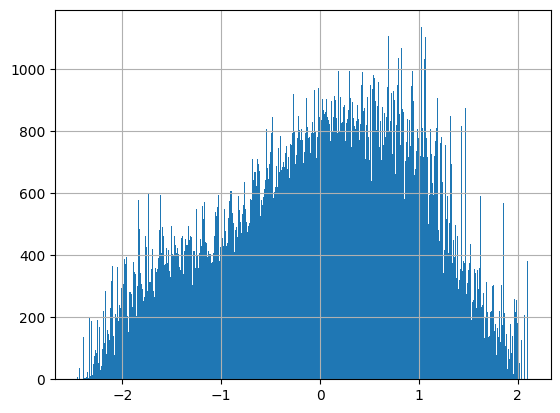

In [45]:
wealth_relevant_info.combined_score.hist(bins=500)

In [46]:
wealth_relevant_info["weighted_household_size"] = (
    wealth_relevant_info.hh_size * wealth_relevant_info.multiplier
)

from statsmodels.stats.weightstats import DescrStatsW

wq = DescrStatsW(
    data=wealth_relevant_info.combined_score,
    weights=wealth_relevant_info.weighted_household_size,
)
quintile_cutoffs = wq.quantile(probs=np.linspace(0, 1, 6))
quintile_cutoffs

p
0.0   -2.453442
0.2   -1.142439
0.4   -0.339699
0.6    0.296405
0.8    0.887782
1.0    2.106418
dtype: float64

In [47]:
wealth_relevant_info["wealth_quintile"] = pd.cut(
    wealth_relevant_info.combined_score,
    quintile_cutoffs,
    labels=[1, 2, 3, 4, 5],
    include_lowest=True,
)
wealth_relevant_info["wealth_quintile"]

0         5
1         4
2         4
3         4
4         4
         ..
261741    5
261742    5
261743    4
261744    5
261745    3
Name: wealth_quintile, Length: 261746, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [48]:
assert wealth_relevant_info.wealth_quintile.notnull().all()

In [49]:
wealth_relevant_info.groupby(
    "wealth_quintile", observed=True
).multiplier.sum() / wealth_relevant_info.multiplier.sum()

wealth_quintile
1    0.194822
2    0.197195
3    0.210537
4    0.198687
5    0.198759
Name: multiplier, dtype: float64

In [50]:
for column in wealth_predictors:
    print(column)
    print(
        wealth_relevant_info.groupby(
            ["wealth_quintile", column], observed=True
        ).multiplier.sum()
        / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum()
    )

land_ownership
wealth_quintile  land_ownership
1                0.0               0.017001
                 1.0               0.982999
2                0.0               0.064876
                 1.0               0.935124
3                0.0               0.121395
                 1.0               0.878605
4                0.0               0.084162
                 1.0               0.915838
5                0.0               0.078404
                 1.0               0.921596
Name: multiplier, dtype: float64
has_dwelling
wealth_quintile  has_dwelling
1                0.0             0.000067
                 1.0             0.999933
2                0.0             0.000251
                 1.0             0.999749
3                1.0             1.000000
4                1.0             1.000000
5                1.0             1.000000
Name: multiplier, dtype: float64
house_ownership
wealth_quintile  house_ownership
1                False              0.023653
                

wealth_quintile  air_conditioner
1                0.0                0.967706
                 1.0                0.032294
2                0.0                0.880995
                 1.0                0.119005
3                0.0                0.821039
                 1.0                0.178961
4                0.0                0.727671
                 1.0                0.272329
5                0.0                0.399835
                 1.0                0.600165
Name: multiplier, dtype: float64
building_material_wall_brick
wealth_quintile  building_material_wall_brick
1                0                               0.593956
                 1                               0.406044
2                0                               0.300867
                 1                               0.699133
3                0                               0.230983
                 1                               0.769017
4                0                               0.208929
   

wealth_quintile  building_material_roof_none
1                0                              0.999933
                 1                              0.000067
2                0                              0.999749
                 1                              0.000251
3                0                              1.000000
4                0                              1.000000
5                0                              1.000000
Name: multiplier, dtype: float64
building_material_roof_pucca
wealth_quintile  building_material_roof_pucca
1                0                               0.979130
                 1                               0.020870
2                0                               0.986882
                 1                               0.013118
3                0                               0.990538
                 1                               0.009462
4                0                               0.993529
                 1                        

wealth_quintile  cooking_energy_source_gobar
1                0                              0.999943
                 1                              0.000057
2                0                              0.999746
                 1                              0.000254
3                0                              0.998945
                 1                              0.001055
4                0                              0.999157
                 1                              0.000843
5                0                              0.999854
                 1                              0.000146
Name: multiplier, dtype: float64
cooking_energy_source_kerosene
wealth_quintile  cooking_energy_source_kerosene
1                0                                 0.999925
                 1                                 0.000075
2                0                                 0.997612
                 1                                 0.002388
3                0               

wealth_quintile  drinking_water_source_piped from neighbor
1                0                                            0.986867
                 1                                            0.013133
2                0                                            0.978866
                 1                                            0.021134
3                0                                            0.981466
                 1                                            0.018534
4                0                                            0.989580
                 1                                            0.010420
5                0                                            0.996726
                 1                                            0.003274
Name: multiplier, dtype: float64
drinking_water_source_piped into dwelling
wealth_quintile  drinking_water_source_piped into dwelling
1                0                                            0.977033
                 1        

wealth_quintile  latrine_access_and_type_improved pit
1                0                                       0.992505
                 1                                       0.007495
2                0                                       0.992974
                 1                                       0.007026
3                0                                       0.993526
                 1                                       0.006474
4                0                                       0.994136
                 1                                       0.005864
5                0                                       0.996169
                 1                                       0.003831
Name: multiplier, dtype: float64
latrine_access_and_type_no latrine
wealth_quintile  latrine_access_and_type_no latrine
1                0                                     0.610420
                 1                                     0.389580
2                0                    

In [51]:
# Whoa, owning land or a house is uncorrelated?!
india_dhs = pd.read_stata(
    "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/IND_DHS7_2015_2016_HH_IAHR74FL_Y2018M12D06.DTA",
    columns=["hv005", "hv270", "sh46"],
).rename(columns={"hv005": "weight", "hv270": "wealth_quintile", "sh46": "owns_house"})

In [52]:
india_dhs.groupby(
    ["wealth_quintile", "owns_house"], observed=True
).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()

wealth_quintile  owns_house
poorest          no            0.174830
                 yes           0.825170
poorer           no            0.179612
                 yes           0.820388
middle           no            0.213271
                 yes           0.786729
richer           no            0.248677
                 yes           0.751323
richest          no            0.191180
                 yes           0.808820
Name: weight, dtype: float64

In [53]:
# Bizarre. Even in DHS it's basically uncorrelated, although in HCES it seems to be reversed.

In [54]:
households["wealth_quintile"] = wealth_relevant_info["wealth_quintile"]

In [55]:
assert households.wealth_quintile.notnull().all()

## Household rice consumption

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.

- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

Units: kg/30 days.

In [56]:
consumption = pd.read_fwf(
    f"{data_dir}/hces22_lvl_05.TXT",
    header=None,
    widths=[38, 1, 2, 3, 10, 8, 10, 8, 1, 15],
    names=[
        "common_id",
        "q_num",
        "level",
        "item_code",
        "consumption_amt_home_produce",
        "consumption_value_home_produce",
        "total_consumption_amt",
        "total_consumption_value",
        "source",
        "multiplier",
    ],
)
consumption = consumption[consumption.item_code.isin([61, 101, 102])]
consumption

,common_id,q_num,level,item_code,consumption_amt_home_produce,consumption_value_home_produce,total_consumption_amt,total_consumption_value,source,multiplier
0,HCES2022655561010131113011 101202 201,F,5,102,NaN,NaN,40,1200.0,1.0,35560.0
26,HCES2022655561010131113011 101202 301,F,5,102,40,950,40,950.0,2.0,30331.0
53,HCES2022655561010131113011 101202 302,F,5,102,30,900,36,1020.0,3.0,30331.0
80,HCES2022655561010131113011 101202 303,F,5,102,NaN,NaN,25,500.0,1.0,30331.0
106,HCES2022655561010131113011 101202 304,F,5,102,20,600,20,600.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...
9314493,HCES20223951022828313220210228101 316,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314531,HCES20223951022828313220210228101 317,F,5,61,NaN,NaN,10.00,NaN,1.0,73515.0
9314532,HCES20223951022828313220210228101 317,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314576,HCES20223951022828313220210228101 318,F,5,61,NaN,NaN,5.00,NaN,1.0,73515.0


In [57]:
consumption["item_code"] = consumption.item_code.map(
    {
        61: "pds free rice",
        101: "pds paid rice",
        102: "other rice",
    }
)
consumption["is_pds"] = consumption.item_code.isin(["pds free rice", "pds paid rice"])

In [58]:
consumption["source"] = consumption.source.map(
    {
        1: "only purchase",
        2: "only home-grown",
        3: "both purchase and home-grown",
        4: "only free collection",
        5: "only exchange",
        6: "only gifts",
        9: "other",
    }
)

In [59]:
consumption["total_consumption_amt"] = consumption.total_consumption_amt.astype(float)
consumption["consumption_amt_home_produce"] = (
    consumption.consumption_amt_home_produce.astype(float)
)

In [60]:
# I assume for these high-missingness columns, null means 0
consumption.isnull().mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.933018
consumption_value_home_produce    0.933031
total_consumption_amt             0.000000
total_consumption_value           0.261820
source                            0.000000
multiplier                        0.000000
is_pds                            0.000000
dtype: float64

In [61]:
(consumption == 0).mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.000272
consumption_value_home_produce    0.000000
total_consumption_amt             0.000000
total_consumption_value           0.000000
source                            0.000000
multiplier                        0.000000
is_pds                            0.530847
dtype: float64

In [62]:
consumption = consumption.fillna(0)

In [63]:
consumption["pds_rice"] = np.where(
    consumption.is_pds,
    consumption.total_consumption_amt,
    0.0,
)

In [64]:
consumption["non_pds_rice_purchased"] = np.where(
    consumption.is_pds,
    0.0,
    np.where(
        consumption.source.isin(["only purchase", "both purchase and home-grown"]),
        consumption.total_consumption_amt - consumption.consumption_amt_home_produce,
        0.0,
    ),
)

In [65]:
consumption["non_pds_rice_non_purchased"] = (
    consumption.total_consumption_amt
    - consumption.pds_rice
    - consumption.non_pds_rice_purchased
)

In [66]:
consumption = consumption.groupby("common_id")[
    ["pds_rice", "non_pds_rice_purchased", "non_pds_rice_non_purchased"]
].sum()
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased
common_id,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0
...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0


In [67]:
consumption["rice"] = consumption.sum(axis=1)
consumption["proportion_non_pds_purchased"] = (
    consumption.non_pds_rice_purchased / (consumption.rice - consumption.pds_rice)
).clip(0, 1)
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
common_id,,,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0
...,...,...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0


In [68]:
len(consumption) / len(households)

0.9688209179891957

In [69]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

0.9688209179891957

In [70]:
consumption = consumption.reindex(households.common_id).fillna(0).reset_index()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
0,HCES2022655561010131113011 101202 201,0.0,40.0,0.0,40.0,1.000000
1,HCES2022655561010131113011 101202 301,0.0,0.0,40.0,40.0,0.000000
2,HCES2022655561010131113011 101202 302,0.0,6.0,30.0,36.0,0.166667
3,HCES2022655561010131113011 101202 303,0.0,25.0,0.0,25.0,1.000000
4,HCES2022655561010131113011 101202 304,0.0,0.0,20.0,20.0,0.000000
...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,10.0,15.0,0.0,25.0,1.000000
261742,HCES20223951022828313220210228101 315,0.0,25.0,0.0,25.0,1.000000
261743,HCES20223951022828313220210228101 316,0.0,25.0,0.0,25.0,1.000000
261744,HCES20223951022828313220210228101 317,10.0,25.0,0.0,35.0,1.000000


In [71]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

0.9688209179891957

## Individual rice consumption

We distribute the rice to the individuals according to the number of meals they have eaten at home.
We assume that children eating school lunches are getting fortified rice, as the scale-up has also
happened through that program.
Otherwise, we assume that meals eaten away from the home use rice and fortified rice at the same rate
as meals at home.

In [72]:
household_members = pd.read_fwf(
    "/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_02.TXT",
    header=None,
    widths=[38, 1, 2, 2, 1, 1, 3, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 1, 15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "person_serial_no",
        "relation_to_head_code",
        "gender",
        "age_years",
        "marital_status_code",
        "highest_education_level_code",
        "total_years_education",
        "internet_use_last_30_days",
        "days_away_from_home_last_30_days",
        "usual_daily_meals",
        "meals_from_school_balwadi_last_30_days",
        "meals_from_employer_last_30_days",
        "meals_others_last_30_days",
        "meals_paid_last_30_days",
        "meals_at_home_last_30_days",
        "member_status_on_revisit",
        "fdq_orig_number",
        "multiplier",
    ],
)
household_members = household_members[
    ["common_id", "gender", "age_years", "multiplier"]
    + [c for c in household_members.columns if "meals" in c]
]
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,NaN,NaN,NaN,NaN,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,NaN,NaN,NaN,NaN,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,NaN,NaN,NaN,NaN,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,NaN,NaN,NaN,NaN,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [73]:
# My interpretation: null basically is equivalent to 0 for these high-missingness columns...
household_members.filter(like="meals").isnull().mean()

usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.650829
meals_from_employer_last_30_days          0.689258
meals_others_last_30_days                 0.617970
meals_paid_last_30_days                   0.640668
meals_at_home_last_30_days                0.007464
dtype: float64

In [74]:
# ... even though there are actual zeros!
(household_members.filter(like="meals") == 0).mean()

usual_daily_meals                         0.007479
meals_from_school_balwadi_last_30_days    0.288050
meals_from_employer_last_30_days          0.304265
meals_others_last_30_days                 0.268969
meals_paid_last_30_days                   0.285900
meals_at_home_last_30_days                0.007285
dtype: float64

In [75]:
for col in [
    "meals_from_school_balwadi_last_30_days",
    "meals_from_employer_last_30_days",
    "meals_others_last_30_days",
    "meals_paid_last_30_days",
]:
    household_members[col] = household_members[col].fillna(0)

In [76]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.007464
dtype: float64

In [77]:
# Complete-case analysis
household_members = household_members.dropna(how="any").copy()
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [78]:
household_members["gender"] = household_members.gender.map(
    {
        1: "Male",
        2: "Female",
        3: "Transgender",
    }
)

In [79]:
household_members = household_members.merge(
    households[["common_id", "wealth_quintile"]],
    on="common_id",
    validate="m:1",
    how="left",
)

In [80]:
assert household_members.wealth_quintile.notnull().all()

In [81]:
household_members["meals"] = (
    household_members.meals_at_home_last_30_days.fillna(0)
    + household_members.meals_from_employer_last_30_days.fillna(0)
    + household_members.meals_from_school_balwadi_last_30_days.fillna(0)
    + household_members.meals_from_employer_last_30_days.fillna(0)
    + household_members.meals_paid_last_30_days.fillna(0)
    + household_members.meals_others_last_30_days.fillna(0)
)

<Axes: xlabel='usual_daily_meals', ylabel='meals'>

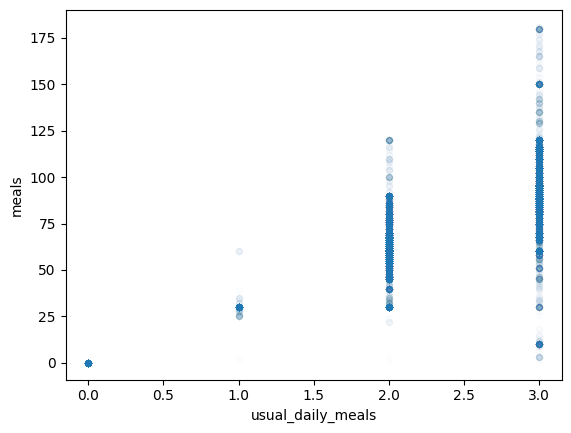

In [82]:
household_members.plot(kind="scatter", x="usual_daily_meals", y="meals", alpha=0.01)

In [83]:
household_meals = household_members.groupby(
    "common_id"
).meals_at_home_last_30_days.sum()
household_meals

common_id
HCES2022310002282831212025 228111  301     30.0
HCES2022310002282831212025 228111  302    408.0
HCES2022310002282831212025 228111  303    450.0
HCES2022310002282831212025 228111  304    180.0
HCES2022310002282831212025 228111  305     30.0
                                          ...  
HCES2022699991212130123093 221201  312    671.0
HCES2022699991212130123093 221201  313    180.0
HCES2022699991212130123093 221201  314    360.0
HCES2022699991212130123093 221201  315    333.0
HCES2022699991212130123093 221201  316    480.0
Name: meals_at_home_last_30_days, Length: 259624, dtype: float64

In [84]:
consumption = consumption.merge(
    household_meals, on="common_id", validate="1:1", how="left"
)
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,0.0,40.0,0.0,40.0,1.000000,286.0
1,HCES2022655561010131113011 101202 301,0.0,0.0,40.0,40.0,0.000000,356.0
2,HCES2022655561010131113011 101202 302,0.0,6.0,30.0,36.0,0.166667,471.0
3,HCES2022655561010131113011 101202 303,0.0,25.0,0.0,25.0,1.000000,236.0
4,HCES2022655561010131113011 101202 304,0.0,0.0,20.0,20.0,0.000000,238.0
...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,10.0,15.0,0.0,25.0,1.000000,180.0
261742,HCES20223951022828313220210228101 315,0.0,25.0,0.0,25.0,1.000000,360.0
261743,HCES20223951022828313220210228101 316,0.0,25.0,0.0,25.0,1.000000,270.0
261744,HCES20223951022828313220210228101 317,10.0,25.0,0.0,35.0,1.000000,450.0


In [85]:
consumption.isnull().mean()

common_id                       0.000000
pds_rice                        0.000000
non_pds_rice_purchased          0.000000
non_pds_rice_non_purchased      0.000000
rice                            0.000000
proportion_non_pds_purchased    0.000000
meals_at_home_last_30_days      0.008107
dtype: float64

In [86]:
consumption = consumption.dropna(how="any").copy()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,0.0,40.0,0.0,40.0,1.000000,286.0
1,HCES2022655561010131113011 101202 301,0.0,0.0,40.0,40.0,0.000000,356.0
2,HCES2022655561010131113011 101202 302,0.0,6.0,30.0,36.0,0.166667,471.0
3,HCES2022655561010131113011 101202 303,0.0,25.0,0.0,25.0,1.000000,236.0
4,HCES2022655561010131113011 101202 304,0.0,0.0,20.0,20.0,0.000000,238.0
...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,10.0,15.0,0.0,25.0,1.000000,180.0
261742,HCES20223951022828313220210228101 315,0.0,25.0,0.0,25.0,1.000000,360.0
261743,HCES20223951022828313220210228101 316,0.0,25.0,0.0,25.0,1.000000,270.0
261744,HCES20223951022828313220210228101 317,10.0,25.0,0.0,35.0,1.000000,450.0


In [87]:
consumption["rice_per_meal_kg"] = np.where(
    consumption.rice == 0,
    0.0,
    consumption.rice / consumption.meals_at_home_last_30_days,
)

In [88]:
# In a small number of cases, rice consumption is reported despite very few or no meals at home
impossible_rice_consumption = (consumption.rice > 0) & (
    consumption.meals_at_home_last_30_days == 0
)
consumption[impossible_rice_consumption]

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days,rice_per_meal_kg
2760,HCES2022664851090951923151 109302 301,0.0,6.0,0.0,6.0,1.0,0.0,inf
9836,HCES2022698761222220723041 222122 303,20.0,10.0,0.0,30.0,1.0,0.0,inf
38661,HCES2022683421272732023262 227136 309,0.0,2.0,0.0,2.0,1.0,0.0,inf
38937,HCES2022681221282810423022 228211 308,5.0,0.0,0.0,5.0,0.0,0.0,inf
46029,HCES2022339822171710622012 217101 313,0.0,5.0,0.0,5.0,1.0,0.0,inf
49295,HCES2022319332272730332022 127111 309,2.0,3.0,0.0,5.0,1.0,0.0,inf
52141,HCES2022342522353510322012 235102 301,0.0,10.0,0.0,10.0,1.0,0.0,inf
63889,HCES2022644111242453023133 124122 306,1.2,0.0,0.0,1.2,0.0,0.0,inf
68063,HCES2022606211363612323103 136101 303,20.0,7.0,0.0,27.0,1.0,0.0,inf
69381,HCES2022357392080820712013 208211 310,0.0,0.1,0.0,0.1,1.0,0.0,inf


In [89]:
# This must be wrong somehow, so we clip it
consumption["rice_per_meal_kg"] = consumption["rice_per_meal_kg"].clip(
    upper=np.percentile(consumption.rice_per_meal_kg, 95)
)

<Axes: >

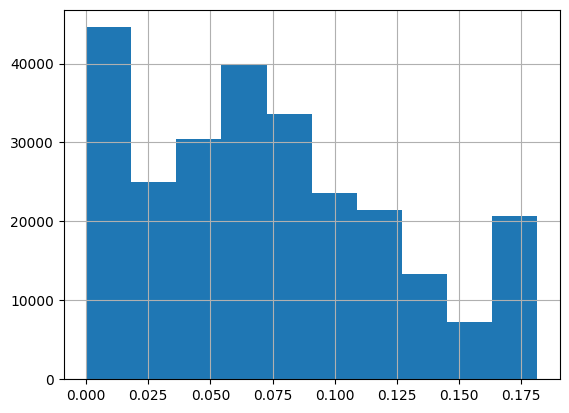

In [90]:
consumption[consumption.rice_per_meal_kg.notnull()].sort_values("rice_per_meal_kg")
consumption.rice_per_meal_kg.hist()

<Axes: >

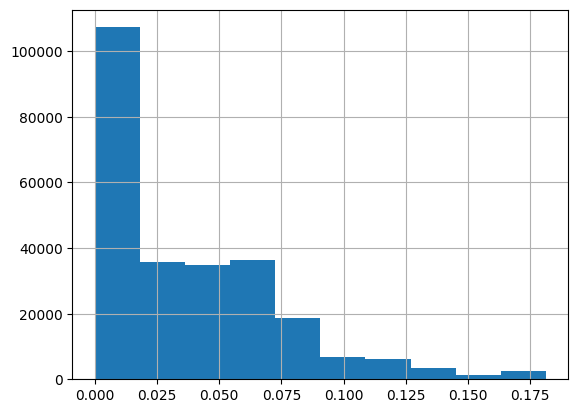

In [91]:
consumption["pds_rice_per_meal_kg"] = consumption.rice_per_meal_kg * (
    consumption.pds_rice / consumption.rice
)
consumption.pds_rice_per_meal_kg.hist()

In [92]:
household_members = household_members.merge(
    consumption.reset_index()[
        [
            "common_id",
            "rice_per_meal_kg",
            "pds_rice_per_meal_kg",
            "proportion_non_pds_purchased",
        ]
    ],
    on="common_id",
    how="left",
    validate="m:1",
)
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,wealth_quintile,meals,rice_per_meal_kg,pds_rice_per_meal_kg,proportion_non_pds_purchased
0,HCES2022655561010131113011 101202 201,Male,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,5,58.0,0.139860,0.000000,1.0
1,HCES2022655561010131113011 101202 201,Female,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0,5,60.0,0.139860,0.000000,1.0
2,HCES2022655561010131113011 101202 201,Male,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,5,58.0,0.139860,0.000000,1.0
3,HCES2022655561010131113011 101202 201,Male,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0,5,56.0,0.139860,0.000000,1.0
4,HCES2022655561010131113011 101202 201,Female,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0,5,54.0,0.139860,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118622,HCES20223492023737102120110201201 313,Male,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0,4,60.0,0.101695,0.067797,1.0
1118623,HCES20223492023737102120110201201 313,Female,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0,4,60.0,0.101695,0.067797,1.0
1118624,HCES20223492023737102120110201201 313,Male,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0,4,60.0,0.101695,0.067797,1.0
1118625,HCES20223492023737102120110201201 313,Female,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0,4,60.0,0.101695,0.067797,1.0


In [93]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
dtype: float64

In [94]:
household_members["government_meals_away_from_home"] = (
    household_members.meals_from_school_balwadi_last_30_days
)
household_members["non_government_meals_away_from_home"] = (
    household_members.meals
    - household_members.meals_at_home_last_30_days
    - household_members.government_meals_away_from_home
)
household_members["rice"] = household_members.meals * household_members.rice_per_meal_kg
household_members["government_rice"] = (
    household_members.meals_at_home_last_30_days
    * household_members.pds_rice_per_meal_kg
    + (
        household_members.government_meals_away_from_home
        * household_members.rice_per_meal_kg
    )
    + (
        household_members.non_government_meals_away_from_home
        * household_members.pds_rice_per_meal_kg
    )  # Assume same as at-home meals
)
household_members["proportion_government"] = (
    household_members.government_rice / household_members.rice
).clip(0, 1)
# NOTE: For now, we say only government rice is fortifiable!
household_members["proportion_fortifiable"] = household_members["proportion_government"]
# (
#     # It's assumed that all non-government rice you consume is fortifiable if it was purchased; we use your household's rate of
#     # purchasing vs growing for non-PDS rice for this.
#     # All government rice is fortifiable.
#     (
#         household_members.government_rice
#         + (
#             household_members.proportion_non_pds_purchased
#             * (household_members.rice - household_members.government_rice)
#         )
#     )
#     / household_members.rice
# )

In [95]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
government_meals_away_from_home           0.000000
non_government_meals_away_from_home       0.000000
rice                                      0.000000
government_rice                           0.017985
proportion_government          

In [96]:
# Convert kg/30 days to g/day
household_members["rice_g_per_day"] = household_members.rice / 30 * 1_000

In [97]:
household_members["sex"] = household_members.gender.replace(
    {"Transgender": np.nan}
)  # We don't know the sex of transgender people in the survey :(
age_bin_edges = [0, 5, 15, 30, 50, 125]
age_group = pd.IntervalIndex(
    pd.cut(household_members.age_years, age_bin_edges, right=False, include_lowest=True)
)
household_members["age_start"] = age_group.left
household_members["age_end"] = age_group.right

In [98]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [99]:
results_dir = "../results/"

In [100]:
import pathlib


def save_data(series, name):
    path = f"{results_dir}/{name}/india.csv"
    pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
    (
        series.rename("value")
        .reset_index()
        .assign(vehicle_name="rice")
        .to_csv(path, index=False)
    )


def save_for_each_fortificant(series, name):
    save_data(series, f"iron/{name}")
    save_data(series, f"folate/{name}")

In [101]:
weighted_avg_and_std(
    household_members.rice_g_per_day > 0, weights=household_members.multiplier
)

mean                          0.973967
sd                            0.159233
effective_sample_size    525630.443074
dtype: float64

In [102]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier)
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.983330,0.128032,48668.325371
2,0.964712,0.184507,139137.334027
3,0.962531,0.189909,161242.433713
4,0.977683,0.147713,155659.783442
5,0.981452,0.134922,140658.162420


In [103]:
# NOTE: We do not have pregnancy status in this survey, so we assume it has no effect on consumption!
any_consumption = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(df.rice_g_per_day.notnull(), df.rice_g_per_day > 0, np.nan),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
any_consumption

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.919076  0.272719   
                         2                0.887756  0.315666   
                         3                0.875160  0.330538   
                         4                0.874946  0.330780   
                         5                0.879201  0.325894   
       5         15      1                0.987435  0.111387   
                         2                0.971206  0.167228   
                         3                0.976108  0.152712   
                         4                0.985006  0.121528   
                         5                0.988478  0.106719   
       15        30      1                0.989477  0.102039   
                         2                0.962284  0.190509   
                         3                0.949051  0.219894   
                         4                0.983526  0.127291   
                         5                0.987731  0.110086   
       30        50      1                0.991169  0.093556   
                         2                0.980521  0.138203   
                         3                0.979261  0.142508   
                         4                0.986777  0.114228   
                         5                0.988428  0.106947   
       50        125     1                0.987300  0.111978   
                         2                0.974118  0.158785   
                         3                0.976547  0.151338   
                         4                0.985705  0.118703   
                         5                0.986855  0.113897   
Male   0         5       1                0.918771  0.273187   
                         2                0.884489  0.319638   
                         3                0.875467  0.330189   
                         4                0.876535  0.328970   
                         5                0.877939  0.327356   
       5         15      1                0.988832  0.105087   
                         2                0.972957  0.162210   
                         3                0.973361  0.161026   
                         4                0.984239  0.124550   
                         5                0.986266  0.116384   
       15        30      1                0.990754  0.095712   
                         2                0.958654  0.199090   
                         3                0.952879  0.211899   
                         4                0.979735  0.140904   
                         5                0.987952  0.109100   
       30        50      1                0.991017  0.094354   
                         2                0.978177  0.146107   
                         3                0.975512  0.154558   
                         4                0.984333  0.124183   
                         5                0.987183  0.112484   
       50        125     1                0.988336  0.107367   
                         2                0.975934  0.153254   
                         3                0.976151  0.152579   
                         4                0.985469  0.119667   
                         5                0.987381  0.111622   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1743.263215  
                         2                          5982.871624  
                         3                          5084.488296  
                         4                          4406.862764  
                         5                          3828.948193  
       5         15      1                          7488.653662  
                         2                          8286.919576  
                         3                         13114.610332  
                         4                         11533.

In [104]:
save_data(any_consumption["mean"], "rice/vehicle_consumption/any")

In [105]:
weighted_avg_and_std(
    household_members.rice_g_per_day, weights=household_members.multiplier
)

mean                        166.827738
sd                          120.192295
effective_sample_size    525630.443074
dtype: float64

In [106]:
(
    household_members.groupby("wealth_quintile")
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,212.264034,123.213287,48668.325371
2,173.583827,121.350848,139137.334027
3,161.967296,118.320720,161242.433713
4,160.563915,116.314280,155659.783442
5,125.712428,104.528120,140658.162420


In [107]:
consumption_amount = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)
consumption_amount

mean          sd  \
sex    age_start age_end wealth_quintile                           
Female 0         5       1                185.559631  121.168311   
                         2                147.531394  116.095056   
                         3                129.130302  110.752293   
                         4                127.809856  108.603282   
                         5                102.815078   95.141765   
       5         15      1                215.163368  120.989510   
                         2                169.661789  117.448466   
                         3                157.826906  112.525742   
                         4                156.308481  111.517447   
                         5                121.855134   98.613841   
       15        30      1                206.658250  119.447794   
                         2                168.712347  118.592026   
                         3                153.034877  115.173905   
                         4                154.403933  112.840694   
                         5                126.165615  104.458984   
       30        50      1                216.769670  123.974671   
                         2                180.227007  122.464593   
                         3                171.532393  119.434941   
                         4                170.113479  118.592201   
                         5                128.315368  105.405824   
       50        125     1                219.526796  128.024153   
                         2                185.859642  126.921591   
                         3                178.723165  124.486746   
                         4                168.918521  117.844015   
                         5                130.416748  105.711529   
Male   0         5       1                185.278819  123.182430   
                         2                146.516138  116.989434   
                         3                129.446363  108.313003   
                         4                124.818321  105.573154   
                         5                100.678651   93.941297   
       5         15      1                216.893196  121.443966   
                         2                172.804443  117.958078   
                         3                159.388125  114.651441   
                         4                154.550355  111.852587   
                         5                121.923356  100.086388   
       15        30      1                213.744900  120.883650   
                         2                172.092404  121.778682   
                         3                155.929784  118.510235   
                         4                158.940278  117.003970   
                         5                125.210198  106.312501   
       30        50      1                213.007652  124.468151   
                         2                175.759177  122.006749   
                         3                164.240333  117.752305   
                         4                164.063506  118.720777   
                         5                125.755082  105.263856   
       50        125     1                221.995374  127.097801   
                         2                185.190235  123.925460   
                         3                176.087660  121.726091   
                         4                170.708637  118.354416   
                         5                133.137342  107.693009   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1743.263215  
                         2                          5982.871624  
                         3                          5084.488296  
                         4                          4406.862764  
                         5                          3828.948193  
       5         15      1                       

In [108]:
save_data(consumption_amount["mean"], "rice/vehicle_consumption/amount/mean")
save_data(consumption_amount["sd"], "rice/vehicle_consumption/amount/sd")

In [109]:
# NOTE: Government rice fortification scale-up is still in progress.
# According to this dashboard (https://impds.nic.in/sale/stateUnautmated?month=1&year=2024) it is
# around 70% in 2024. We say that it can't get above 80% due to compliance issues.
# We apply maximum individual heterogeneity, meaning that the people who are missed
# due to compliance are *completely* missed.
GOVERNMENT_BASELINE_COVERAGE = 0.8

In [110]:
weighted_avg_and_std(
    GOVERNMENT_BASELINE_COVERAGE * household_members.proportion_government,
    weights=household_members.multiplier,
)

mean                          0.379905
sd                            0.308381
effective_sample_size    509029.997552
dtype: float64

In [111]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(
            GOVERNMENT_BASELINE_COVERAGE * df.proportion_government,
            weights=df.multiplier,
        )
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.462200,0.270790,47287.386492
2,0.463758,0.289958,134271.649141
3,0.417485,0.308884,157794.204228
4,0.360607,0.308915,152309.947954
5,0.197934,0.280279,138238.091656


In [112]:
any_fortification = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(
                df.proportion_government.notnull(),
                GOVERNMENT_BASELINE_COVERAGE * (df.proportion_government > 0),
                np.nan,
            ),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
any_fortification

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.610227  0.340301   
                         2                0.603021  0.344649   
                         3                0.562766  0.365386   
                         4                0.519586  0.381706   
                         5                0.333848  0.394492   
       5         15      1                0.722657  0.236416   
                         2                0.691105  0.274332   
                         3                0.639364  0.320476   
                         4                0.577194  0.358612   
                         5                0.364202  0.398395   
       15        30      1                0.649086  0.312979   
                         2                0.636175  0.322834   
                         3                0.574530  0.359916   
                         4                0.522744  0.380702   
                         5                0.337505  0.395088   
       30        50      1                0.696627  0.268351   
                         2                0.658639  0.305132   
                         3                0.600692  0.346010   
                         4                0.544891  0.372836   
                         5                0.316426  0.391172   
       50        125     1                0.705847  0.257793   
                         2                0.668254  0.296715   
                         3                0.613275  0.338399   
                         4                0.547941  0.371636   
                         5                0.316034  0.391088   
Male   0         5       1                0.615059  0.337268   
                         2                0.607957  0.341692   
                         3                0.557434  0.367715   
                         4                0.518145  0.382154   
                         5                0.317236  0.391344   
       5         15      1                0.725549  0.232417   
                         2                0.686029  0.279620   
                         3                0.627803  0.328794   
                         4                0.569429  0.362345   
                         5                0.350111  0.396877   
       15        30      1                0.685312  0.280351   
                         2                0.636577  0.322539   
                         3                0.556441  0.368139   
                         4                0.525810  0.379700   
                         5                0.329407  0.393721   
       30        50      1                0.673414  0.291967   
                         2                0.636213  0.322805   
                         3                0.568510  0.362773   
                         4                0.529947  0.378304   
                         5                0.310716  0.389908   
       50        125     1                0.705239  0.258513   
                         2                0.665009  0.299617   
                         3                0.607741  0.341824   
                         4                0.543890  0.373223   
                         5                0.313873  0.390618   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1503.844854  
                         2                          5291.275282  
                         3                          4485.976336  
                         4                          3879.176497  
                         5                          3450.504018  
       5         15      1                          7341.325826  
                         2                          7936.785902  
                         3                         12751.097252  
                         4                         11339.

In [113]:
save_for_each_fortificant(
    any_fortification["mean"], "rice/baseline_fortification/any_coverage"
)

In [114]:
full_fortification = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            np.where(
                df.proportion_government.notnull(),
                GOVERNMENT_BASELINE_COVERAGE * (df.proportion_government == 1),
                np.nan,
            ),
            weights=df.multiplier,
        )
    )
    .sort_index()
)
full_fortification

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.173331  0.329577   
                         2                0.198508  0.345545   
                         3                0.200478  0.346686   
                         4                0.146602  0.309499   
                         5                0.073288  0.230780   
       5         15      1                0.191211  0.341185   
                         2                0.216787  0.355574   
                         3                0.199139  0.345911   
                         4                0.156480  0.317330   
                         5                0.081990  0.242630   
       15        30      1                0.179032  0.333426   
                         2                0.216343  0.355345   
                         3                0.196778  0.344530   
                         4                0.161062  0.320794   
                         5                0.086765  0.248765   
       30        50      1                0.194468  0.343157   
                         2                0.225326  0.359846   
                         3                0.202337  0.347749   
                         4                0.155295  0.316417   
                         5                0.075662  0.234105   
       50        125     1                0.236077  0.364869   
                         2                0.238967  0.366154   
                         3                0.209957  0.351971   
                         4                0.159428  0.319570   
                         5                0.069474  0.225284   
Male   0         5       1                0.178475  0.333056   
                         2                0.211038  0.352553   
                         3                0.194758  0.343330   
                         4                0.147212  0.309997   
                         5                0.080049  0.240065   
       5         15      1                0.194330  0.343074   
                         2                0.221578  0.358002   
                         3                0.201264  0.347137   
                         4                0.160048  0.320036   
                         5                0.082102  0.242778   
       15        30      1                0.194437  0.343138   
                         2                0.220731  0.357579   
                         3                0.203393  0.348347   
                         4                0.168107  0.325923   
                         5                0.089099  0.251676   
       30        50      1                0.185239  0.337458   
                         2                0.217711  0.356049   
                         3                0.191985  0.341657   
                         4                0.150706  0.312814   
                         5                0.074434  0.232394   
       50        125     1                0.220561  0.357493   
                         2                0.224795  0.359587   
                         3                0.198012  0.345255   
                         4                0.153874  0.315313   
                         5                0.069828  0.225802   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1503.844854  
                         2                          5291.275282  
                         3                          4485.976336  
                         4                          3879.176497  
                         5                          3450.504018  
       5         15      1                          7341.325826  
                         2                          7936.785902  
                         3                         12751.097252  
                         4                         11339.

In [115]:
save_for_each_fortificant(
    full_fortification["mean"], "rice/baseline_fortification/full_coverage"
)

In [116]:
# Remember, we've assumed maximum heterogeneity here, so the people who are partially covered
# have *all* of their government rice fortified.
partial_fortification_amount = (
    household_members[
        (household_members.proportion_government > 0)
        & (household_members.proportion_government < 1)
    ]
    .groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(
        lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier)
    )
    .sort_index()
)
partial_fortification_amount

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.524382  0.203527   
                         2                0.552721  0.193385   
                         3                0.551125  0.205578   
                         4                0.530210  0.214187   
                         5                0.471885  0.212866   
       5         15      1                0.566689  0.206855   
                         2                0.565275  0.216972   
                         3                0.560457  0.227338   
                         4                0.535734  0.224606   
                         5                0.477592  0.223359   
       15        30      1                0.535427  0.189955   
                         2                0.563819  0.187441   
                         3                0.558023  0.196571   
                         4                0.538286  0.204136   
                         5                0.495222  0.210662   
       30        50      1                0.538643  0.184784   
                         2                0.558521  0.189831   
                         3                0.553285  0.197847   
                         4                0.526279  0.202554   
                         5                0.482992  0.208895   
       50        125     1                0.537443  0.185419   
                         2                0.557967  0.187484   
                         3                0.547906  0.195957   
                         4                0.516136  0.202575   
                         5                0.470699  0.205986   
Male   0         5       1                0.532374  0.200598   
                         2                0.558836  0.195566   
                         3                0.556791  0.205189   
                         4                0.529620  0.217144   
                         5                0.486610  0.204447   
       5         15      1                0.567170  0.206978   
                         2                0.572410  0.216182   
                         3                0.556877  0.223415   
                         4                0.543621  0.223986   
                         5                0.483479  0.224121   
       15        30      1                0.536914  0.187172   
                         2                0.563922  0.187654   
                         3                0.565248  0.197746   
                         4                0.538013  0.202756   
                         5                0.501369  0.209181   
       30        50      1                0.540037  0.187875   
                         2                0.559057  0.191238   
                         3                0.556129  0.199491   
                         4                0.530613  0.205464   
                         5                0.488715  0.212137   
       50        125     1                0.538116  0.184038   
                         2                0.558070  0.188781   
                         3                0.549757  0.198223   
                         4                0.520806  0.202515   
                         5                0.471630  0.203321   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                           768.000671  
                         2                          2664.573354  
                         3                          2037.290517  
                         4                          1796.303455  
                         5                          1065.584188  
       5         15      1                          5185.031778  
                         2                          3578.621728  
                         3                          6986.144560  
                         4                          6002.

In [117]:
save_for_each_fortificant(
    partial_fortification_amount["mean"],
    "rice/baseline_fortification/partial_coverage_amount/mean",
)
save_for_each_fortificant(
    partial_fortification_amount["sd"],
    "rice/baseline_fortification/partial_coverage_amount/sd",
)

In [118]:
weighted_avg_and_std(
    household_members.proportion_government, weights=household_members.multiplier
)

mean                          0.474881
sd                            0.385476
effective_sample_size    509029.997552
dtype: float64

In [119]:
proportion_government = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier)
    )
    .sort_index()
)
proportion_government

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.503039  0.369334   
                         2                0.527613  0.378342   
                         3                0.500180  0.396368   
                         4                0.430452  0.387840   
                         5                0.245303  0.344558   
       5         15      1                0.615470  0.319326   
                         2                0.606134  0.347778   
                         3                0.557332  0.373623   
                         4                0.477339  0.381071   
                         5                0.270965  0.356550   
       15        30      1                0.538390  0.351529   
                         2                0.566315  0.367397   
                         3                0.509466  0.389484   
                         4                0.444688  0.391685   
                         5                0.263671  0.360151   
       30        50      1                0.581191  0.329930   
                         2                0.584176  0.358995   
                         3                0.528426  0.381590   
                         4                0.450414  0.382243   
                         5                0.239937  0.346912   
       50        125     1                0.610690  0.334599   
                         2                0.598119  0.356210   
                         3                0.538671  0.378132   
                         4                0.449942  0.382282   
                         5                0.231912  0.338261   
Male   0         5       1                0.513627  0.368665   
                         2                0.541064  0.380749   
                         3                0.495866  0.396479   
                         4                0.429582  0.389094   
                         5                0.244333  0.350655   
       5         15      1                0.619527  0.318041   
                         2                0.609293  0.350843   
                         3                0.548492  0.377747   
                         4                0.478245  0.385022   
                         5                0.264599  0.357425   
       15        30      1                0.572493  0.337162   
                         2                0.569044  0.368388   
                         3                0.503691  0.398490   
                         4                0.450695  0.393465   
                         5                0.261978  0.362483   
       30        50      1                0.561090  0.340926   
                         2                0.564597  0.368784   
                         3                0.501727  0.390572   
                         4                0.439921  0.385142   
                         5                0.237386  0.347167   
       50        125     1                0.601717  0.331046   
                         2                0.588081  0.355163   
                         3                0.529079  0.377500   
                         4                0.446246  0.381361   
                         5                0.231159  0.338108   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1503.844854  
                         2                          5291.275282  
                         3                          4485.976336  
                         4                          3879.176497  
                         5                          3450.504018  
       5         15      1                          7341.325826  
                         2                          7936.785902  
                         3                         12751.097252  
                         4                         11339.

In [120]:
# Save locally for further scaling in the extraction notebook
proportion_government["mean"].rename("value").to_csv(
    "india_proportion_government_rice.csv"
)

In [121]:
(
    household_members.groupby("wealth_quintile")
    .apply(
        lambda df: weighted_avg_and_std(
            df.proportion_fortifiable, weights=df.multiplier
        )
    )
    .sort_index()
)

,mean,sd,effective_sample_size
wealth_quintile,,,
1,0.577750,0.338487,47287.386492
2,0.579698,0.362448,134271.649141
3,0.521856,0.386105,157794.204228
4,0.450759,0.386144,152309.947954
5,0.247418,0.350349,138238.091656


In [122]:
fortifiability_disparities = (
    household_members.groupby(
        ["sex", "age_start", "age_end", "wealth_quintile"], observed=True
    )
    .apply(
        lambda df: weighted_avg_and_std(
            df.proportion_fortifiable, weights=df.multiplier
        )
    )
    .sort_index()
)
fortifiability_disparities

mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0         5       1                0.503039  0.369334   
                         2                0.527613  0.378342   
                         3                0.500180  0.396368   
                         4                0.430452  0.387840   
                         5                0.245303  0.344558   
       5         15      1                0.615470  0.319326   
                         2                0.606134  0.347778   
                         3                0.557332  0.373623   
                         4                0.477339  0.381071   
                         5                0.270965  0.356550   
       15        30      1                0.538390  0.351529   
                         2                0.566315  0.367397   
                         3                0.509466  0.389484   
                         4                0.444688  0.391685   
                         5                0.263671  0.360151   
       30        50      1                0.581191  0.329930   
                         2                0.584176  0.358995   
                         3                0.528426  0.381590   
                         4                0.450414  0.382243   
                         5                0.239937  0.346912   
       50        125     1                0.610690  0.334599   
                         2                0.598119  0.356210   
                         3                0.538671  0.378132   
                         4                0.449942  0.382282   
                         5                0.231912  0.338261   
Male   0         5       1                0.513627  0.368665   
                         2                0.541064  0.380749   
                         3                0.495866  0.396479   
                         4                0.429582  0.389094   
                         5                0.244333  0.350655   
       5         15      1                0.619527  0.318041   
                         2                0.609293  0.350843   
                         3                0.548492  0.377747   
                         4                0.478245  0.385022   
                         5                0.264599  0.357425   
       15        30      1                0.572493  0.337162   
                         2                0.569044  0.368388   
                         3                0.503691  0.398490   
                         4                0.450695  0.393465   
                         5                0.261978  0.362483   
       30        50      1                0.561090  0.340926   
                         2                0.564597  0.368784   
                         3                0.501727  0.390572   
                         4                0.439921  0.385142   
                         5                0.237386  0.347167   
       50        125     1                0.601717  0.331046   
                         2                0.588081  0.355163   
                         3                0.529079  0.377500   
                         4                0.446246  0.381361   
                         5                0.231159  0.338108   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0         5       1                          1503.844854  
                         2                          5291.275282  
                         3                          4485.976336  
                         4                          3879.176497  
                         5                          3450.504018  
       5         15      1                          7341.325826  
                         2                          7936.785902  
                         3                         12751.097252  
                         4                         11339.

In [123]:
# Save locally for further scaling in the extraction notebook
fortifiability_disparities["mean"].rename("value").to_csv(
    "india_rice_fortifiability_disparities.csv"
)